### NIH Alzheimer's Research Funding vs State-Level Disease Burden

### Research Question

At the U.S. state level (2018-2023), how is NIH Alzheimer's research funding associated with state-level Alzheimer's burden (age-adjusted mortality rates, 65+ and 85+ populations), after controlling for state research capacity (number of R1 universities, prior NIH funding), and socioeconomic factors (median income, healthcare expenditure per capita)? Additionally, does funding allocation show temporal lag responses to increasing disease burden, and do geographic regions exhibit funding disparities independent of burden?

### Python Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import numpy as np

import glob

from sklearn.preprocessing import StandardScaler

## Load CDC Data

In [ ]:
final_df = None

for f in glob.glob("CDC data (2018-2023)/*"):
    print(f)
    df = pd.read_csv(f, quotechar='"', escapechar='\\', engine='python')
    df = df[~df['Year'].isna()]
    df['Year'] = df['Year'].astype(int)
    df['Year Code'] = df['Year Code'].astype(int)
    df['State Code'] = df['State Code'].astype(int)
    df['County Code'] = df['County Code'].astype(int)
    df['Deaths'] = df['Deaths'].astype(int)

    if final_df is None:
        final_df = df
    else:
        final_df = pd.concat([final_df, df])
final_df.head()

AttributeError: 'NoneType' object has no attribute 'head'

In [ ]:
final_df[["State", "Year"]].groupby("State").nunique()

,Year
State,
Alabama,5
Alaska,5
Arizona,5
Arkansas,5
California,5
Colorado,5
Connecticut,5
Delaware,5
District of Columbia,5


### Definitions of CDC WONDER Columns

* **Notes** – Additional comments or flags attached to the record.
* **Year** – The calendar year of the death data.
* **Year Code** – Numeric code corresponding to the calendar year.
* **State** – U.S. state in which the deaths occurred.
* **State Code** – Numeric FIPS code for the state.
* **County** – County name and state abbreviation for the death record.
* **County Code** – Numeric FIPS code for the county.
* **Five-Year Age Groups** – Age group category in five-year intervals.
* **Five-Year Age Groups Code** – Numeric or short code representing the age group.
* **Sex** – Reported sex of the decedent.
* **Sex Code** – Abbreviated sex identifier (e.g., M, F).
* **Deaths** – Number of deaths recorded for the demographic group.
* **Population** – Population estimate for the group used to calculate rates.
* **Crude Rate** – Deaths per population without age adjustment.
* **% of Total Deaths** – Percentage of all deaths accounted for by this group.

### Load Income and Population Data

In [ ]:
per_capita_income = pd.read_csv("acs_income.csv")

pop = pd.read_csv("acs_population.csv")

median_income = pd.read_csv("acs_median_income.csv")

### Plot Missing Values

In [ ]:
def plot_missing_percentage(df):
    """
    Plots percentage of missing values for each column.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame
    """

    for c in df.columns:
        df[c] = df[c].replace("Not Applicable", None, regex = False)

    # Calculate missing percentage per column
    missing_percent = (df.isnull().sum() / len(df)) * 100

    # Plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(missing_percent.index, missing_percent.values)

    plt.ylabel("Percentage of Missing Values (%)")
    plt.title("Missing Values Percentage by Column")
    plt.xticks(rotation=90)

    # Add percentage labels on each bar
    for bar, pct in zip(bars, missing_percent.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%",
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

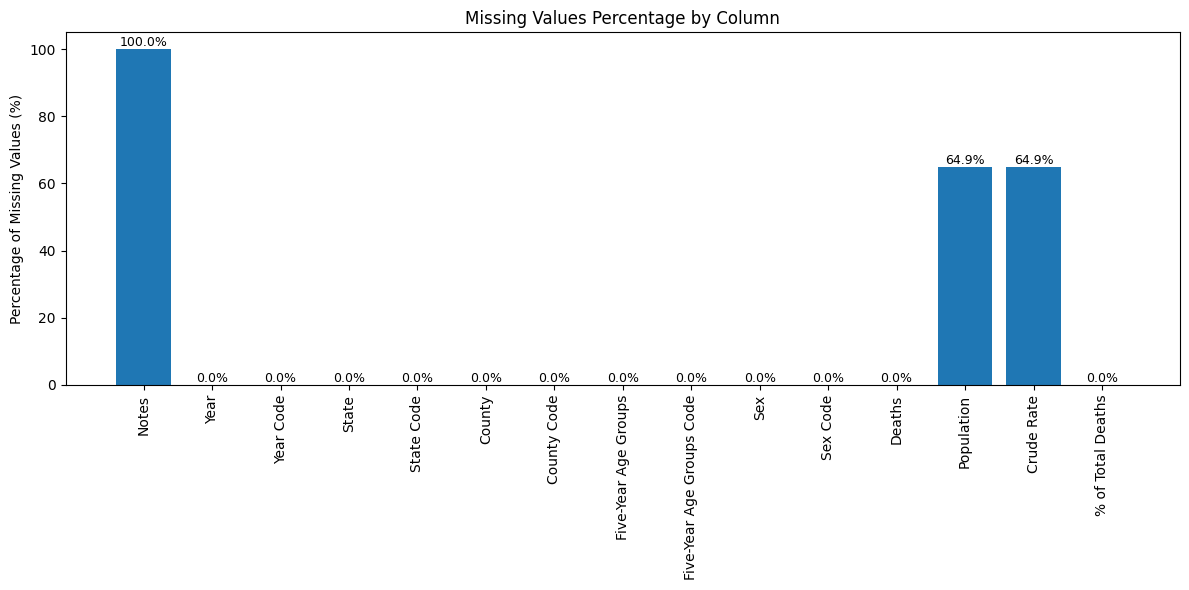

In [ ]:
plot_missing_percentage(final_df)

### What Was the Problem? --> Missing Population!!!

The core issue was that the **Population column contained mixed data types**, including valid numbers and string placeholders such as `"Not Applicable"` and `"Not Available"`. This prevented direct numerical analysis and aggregation.

---

### How we solved the problem?

1. **Standardize percentage values**
   The `% of Total Deaths` column originally contained percentage symbols and string values. These were removed and converted to numeric floats so the column could be used in mathematical calculations.

2. **Derive missing population values (Not Applicable)**
   For rows where `Population` was marked as `"Not Applicable"`, population was calculated using the formula:
   
   $$ \text{Population} = \frac{\text{Deaths}}{\% \text{ of Total Deaths}}$$
   
   This uses available death counts and relative contribution to total deaths to infer population size.

3. **Prepare population values for aggregation**
   A temporary numeric column (`Population_A`) was created by coercing population values to numeric, allowing aggregation while safely handling non-numeric entries.

4. **Impute remaining missing values (Not Available)**
   For rows where population was `"Not Available"`, values were imputed using the **mean population within the same Year, State, County, and Sex group**, preserving demographic and geographic consistency.

5. **Finalize and clean the dataset**
   The population column was converted to integers, and the temporary helper column was removed to leave a clean, analysis-ready dataset.

---

In [ ]:
# 1. Convert % column to numeric once
final_df['pct_total_deaths'] = (
    final_df['% of Total Deaths']
    .str.rstrip('%')
    .astype(float)
)

# 2. Convert Population to numeric (NaN for non-numeric)
final_df['Population_num'] = pd.to_numeric(final_df['Population'], errors='coerce')

# 3. Calculate Population where value is "Not Applicable"
mask_na = final_df['Population'].isna()

final_df.loc[mask_na, 'Population_num'] = (
    final_df.loc[mask_na, 'Deaths'] /
    final_df.loc[mask_na, 'pct_total_deaths']
)

# 4. Fill remaining missing Population using group mean
group_mean = (
    final_df
    .groupby(['Year', 'State', 'County', 'Sex'])['Population_num']
    .transform('mean').round()
)

final_df['Population_num'] = final_df['Population_num'].fillna(group_mean)

# 5. Finalize Population column
final_df['Population'] = final_df['Population_num'].round().astype('Int64')

# 6. Cleanup helper columns
final_df.drop(columns=['Population_num', 'pct_total_deaths'], inplace=True)

In [ ]:
final_df[["State", "Year"]].groupby("State").nunique()

,Year
State,
Alabama,5
Alaska,5
Arizona,5
Arkansas,5
California,5
Colorado,5
Connecticut,5
Delaware,5
District of Columbia,5


### Save preprocessed data

In [ ]:
final_df.to_csv("cdc_wonder_data_cleaned.csv", index=False)

### Filter to 2018-2023

In [ ]:
print(f"Total rows = {final_df.shape[0]}")
final_df = final_df[(final_df['Year'] >= 2018) & (final_df['Year'] <= 2023)]
print(f"Total rows from 2018 to 2023 = {final_df.shape[0]}")

Total rows = 13402
Total rows from 2018 to 2023 = 13402



    ╔════════════════════════════════════════════════════════════════════════╗
    ║                                                                        ║
    ║   ALZHEIMER'S RESEARCH FUNDING ANALYSIS                                ║
    ║   Feature Engineering & Dataset Aggregation Pipeline                   ║
    ║                                                                        ║
    ║   Research Question:                                                   ║
    ║   How is NIH funding associated with Alzheimer's burden at the         ║
    ║   state level (2018-2023), controlling for research capacity and       ║
    ║   socioeconomic factors, with temporal lag analysis?                   ║
    ║                                                                        ║
    ╚════════════════════════════════════════════════════════════════════════╝


### Disease Burden Features

In [ ]:
def create_disease_burden_features(df):
    """
    Category A: Disease Burden Features

    Creates mortality rates, death counts, and temporal trends that represent
    the severity and trajectory of Alzheimer's disease in each state.
    These are critical for measuring need and should theoretically drive funding.
    """
    print("\n[CDC] Creating Disease Burden Features...")

    # A1. Mortality Metrics
    state_year = df.groupby(['State', 'Year']).agg({
        'Deaths': 'sum',
    }).reset_index()

    state_year = state_year.merge(pop, on = ['State', 'Year'], how = "left")

    # Total deaths
    state_year['Total_Deaths_Annual'] = state_year['Deaths']

    # Mortality rate per 100k
    state_year['Mortality_Rate_Per_100k'] = (
        state_year['Deaths'] / state_year['Population'] * 100000
    )

    # Calculate mortality rank within each year
    state_year['Mortality_Rank_National'] = state_year.groupby('Year')[
        'Mortality_Rate_Per_100k'].rank(ascending=False, method='min')

    state_year['Mortality_Percentile'] = state_year.groupby('Year')[
        'Mortality_Rate_Per_100k'].rank(pct=True) * 100

    print(f"   ✓ Created 6 mortality metrics")

    # A2. Temporal Trends
    state_year = state_year.sort_values(['State', 'Year'])

    # Year-over-year changes
    state_year['Mortality_YoY_Change_Pct'] = state_year.groupby('State')[
        'Mortality_Rate_Per_100k'].pct_change() * 100

    state_year['Deaths_YoY_Change_Pct'] = state_year.groupby('State')[
        'Deaths'].pct_change() * 100

    # 3-year rolling average
    state_year['Mortality_3Yr_Rolling_Avg'] = state_year.groupby('State')[
        'Mortality_Rate_Per_100k'].transform(lambda x: x.rolling(3, min_periods=1).mean())

    # Mortality trend (slope over available years)
    def calculate_trend_slope(group):
        if len(group) < 3:
            return np.nan
        x = np.arange(len(group))
        y = group.values
        if np.all(np.isnan(y)):
            return np.nan
        slope, _ = np.polyfit(x[~np.isnan(y)], y[~np.isnan(y)], 1) if np.sum(~np.isnan(y)) >= 2 else (np.nan, np.nan)
        return slope

    state_year['Mortality_Trend_Slope'] = state_year.groupby('State')[
        'Mortality_Rate_Per_100k'].transform(calculate_trend_slope)

    # Cumulative deaths
    state_year['Deaths_Cumulative_2018'] = state_year.groupby('State')[
        'Deaths'].cumsum()

    # Volatility (rolling std)
    state_year['Mortality_Volatility'] = state_year.groupby('State')[
        'Mortality_Rate_Per_100k'].transform(lambda x: x.rolling(3, min_periods=1).std())

    print(f"   ✓ Created 6 temporal trend features")

    # A3. Geographic Distribution (county-level)
    if 'County' in df.columns:
        county_stats = df.groupby(['State', 'Year', 'County']).agg({
            'Deaths': 'sum'
        }).reset_index()

        # Top 3 counties' share of deaths
        def top3_concentration(group):
            if len(group) < 1:
                return np.nan
            top3 = group.nlargest(3, 'Deaths')['Deaths'].sum()
            total = group['Deaths'].sum()
            return (top3 / total * 100) if total > 0 else np.nan

        county_conc = county_stats.groupby(['State', 'Year']).apply(
            top3_concentration
        ).reset_index(name='County_Burden_Concentration')

        state_year = state_year.merge(county_conc, on=['State', 'Year'], how='left')

        # Number of high-burden counties (>100 deaths)
        high_burden = county_stats[county_stats['Deaths'] > 100].groupby(
            ['State', 'Year']).size().reset_index(name='High_Burden_County_Count')

        state_year = state_year.merge(high_burden, on=['State', 'Year'], how='left')
        state_year['High_Burden_County_Count'] = state_year['High_Burden_County_Count'].fillna(0)

        print(f"   ✓ Created 2 geographic distribution features")

    burden_features = state_year
    return burden_features

In [ ]:
final_df['Five-Year Age Groups'].unique()

array(['90-94 years', '95-99 years', '80-84 years', '85-89 years',
       '75-79 years', '60-64 years ', '65-69 years', '70-74 years',
       '100+ years', '55-59 years'], dtype=object)

### Demographic Features

In [ ]:
def create_demographic_features(df):
    """
    Category B: Demographic Features

    Captures at-risk populations (65+, 85+) which are critical for understanding
    future burden and research priorities. Age is the #1 risk factor for Alzheimer's.
    """
    print("\n[CDC] Creating Demographic Features...")

    # Define age groups
    age_65plus = ['65-69 years', '70-74 years', '75-79 years', '80-84 years',
                  '85-89 years', '90-94 years', '95-99 years', '100+ years']

    age_85plus = ['85-89 years', '90-94 years', '95-99 years', '100+ years']

    age_75_84 = ['75-79 years', '80-84 years']

    if 'Five-Year Age Groups' in df.columns:
        # Calculate by age group
        df_65plus = df[df['Five-Year Age Groups'].isin(age_65plus)]
        df_85plus = df[df['Five-Year Age Groups'].isin(age_85plus)]
        df_75_84 = df[df['Five-Year Age Groups'].isin(age_75_84)]

        pop_data = df[['State', 'Year']].drop_duplicates(subset = ['State', 'Year'])
        pop_data = pop_data.merge(pop, on = ['State', 'Year'], how = 'left')

        pop_data.columns = ['State', 'Year', 'Total_Population']

        # 65+ population
        pop_65 = df_65plus.groupby(['State', 'Year'])['Population'].sum().reset_index()
        pop_65.columns = ['State', 'Year', 'Population_65plus']

        # 85+ population
        pop_85 = df_85plus.groupby(['State', 'Year'])['Population'].sum().reset_index()
        pop_85.columns = ['State', 'Year', 'Population_85plus']

        # 75-84 population
        pop_75 = df_75_84.groupby(['State', 'Year'])['Population'].sum().reset_index()
        pop_75.columns = ['State', 'Year', 'Population_75_84']

        # Merge all
        pop_data = pop_data.merge(pop_65, on=['State', 'Year'], how='left')
        pop_data = pop_data.merge(pop_85, on=['State', 'Year'], how='left')
        pop_data = pop_data.merge(pop_75, on=['State', 'Year'], how='left')

    # Calculate percentages
    pop_data['Pct_Population_65plus'] = (
        pop_data['Population_65plus'] / pop_data['Total_Population'] * 100
    )
    pop_data['Pct_Population_85plus'] = (
        pop_data['Population_85plus'] / pop_data['Total_Population'] * 100
    )
    pop_data['Pct_Population_75_84'] = (
        pop_data['Population_75_84'] / pop_data['Total_Population'] * 100
    )

    # Elderly dependency ratio (65+ / 18-64)
    # Assuming working age is ~62% of population (US average)
    pop_data['Working_Age_Population'] = pop_data['Total_Population'] * 0.62
    pop_data['Elderly_Dependency_Ratio'] = (
        pop_data['Population_65plus'] / pop_data['Working_Age_Population'] * 100
    )

    # Very old ratio (85+ as % of 65+)
    pop_data['Very_Old_Ratio'] = (
        pop_data['Population_85plus'] / pop_data['Population_65plus'] * 100
    )

    # YoY growth rates
    pop_data = pop_data.sort_values(['State', 'Year'])
    pop_data['Age_65plus_YoY_Growth'] = pop_data.groupby('State')[
        'Population_65plus'].pct_change() * 100
    pop_data['Age_85plus_YoY_Growth'] = pop_data.groupby('State')[
        'Population_85plus'].pct_change() * 100

    print(f"   ✓ Created {len([c for c in pop_data.columns if c not in ['State', 'Year']])} demographic features")

    demographic_features = pop_data
    return demographic_features

In [ ]:
create_demographic_features(final_df).head(30)


[CDC] Creating Demographic Features...
   ✓ Created 12 demographic features


,State,Year,Total_Population,Population_65plus,Population_85plus,Population_75_84,Pct_Population_65plus,Pct_Population_85plus,Pct_Population_75_84,Working_Age_Population,Elderly_Dependency_Ratio,Very_Old_Ratio,Age_65plus_YoY_Growth,Age_85plus_YoY_Growth
0,Alabama,2019,4876250,121044,44938,76106,2.482317,0.921569,1.560749,3023275.00,4.003738,37.125343,<NA>,<NA>
51,Alabama,2020,4893186,170981,62292,89672,3.494267,1.273036,1.832589,3033775.32,5.635915,36.432118,41.255246,38.617651
102,Alabama,2021,4997675,189790,50391,88854,3.797566,1.008289,1.777907,3098558.50,6.125106,26.550925,11.000637,-19.105182
153,Alabama,2022,5028092,154445,41284,95952,3.071642,0.821067,1.908318,3117417.04,4.954262,26.730551,-18.623215,-18.072672
204,Alabama,2023,5054253,114535,33063,81472,2.266111,0.654162,1.611949,3133636.86,3.655018,28.867159,-25.840914,-19.913284
1,Alaska,2019,737068,3080,1250,1830,0.417872,0.169591,0.248281,456982.16,0.673987,40.584416,<NA>,<NA>
52,Alaska,2020,736990,4179,4179,<NA>,0.567036,0.567036,<NA>,456933.80,0.914574,100.0,35.681818,234.32
103,Alaska,2021,735951,1154,1154,<NA>,0.156804,0.156804,<NA>,456289.62,0.25291,100.0,-72.385738,-72.385738
154,Alaska,2022,734821,4439,2436,2003,0.604093,0.331509,0.272583,455589.02,0.974343,54.877225,284.662045,111.091854
205,Alaska,2023,733971,2041,<NA>,2041,0.278076,<NA>,0.278076,455062.02,0.44851,<NA>,-54.021176,0.0


### Sex-Specific Features

In [ ]:
def create_sex_specific_features(df):
    """
    Create sex-specific mortality patterns

    Women have higher Alzheimer's rates and live longer, affecting burden patterns.
    """
    print("\n[CDC] Creating Sex-Specific Features...")

    if 'Sex' not in df.columns:
        print("   ⚠ Sex column not found, skipping sex-specific features")
        return self

    sex_data = df.groupby(['State', 'Year', 'Sex']).agg({
        'Deaths': 'sum'
    }).reset_index()

    sex_data = sex_data.merge(pop, on = ['State', 'Year'], how = 'left')

    sex_data['Mortality_Rate'] = sex_data['Deaths'] / sex_data['Population'] * 100000

    # Pivot to get male/female rates
    sex_pivot = sex_data.pivot_table(
        index=['State', 'Year'],
        columns='Sex',
        values=['Deaths', 'Mortality_Rate'],
        aggfunc='sum'
    ).reset_index()

    # Flatten column names
    sex_pivot.columns = ['_'.join(col).strip('_') for col in sex_pivot.columns.values]

    # Calculate ratios
    if 'Deaths_Female' in sex_pivot.columns and 'Deaths_Male' in sex_pivot.columns:
        sex_pivot['Female_Male_Death_Ratio'] = (
            sex_pivot['Deaths_Female'] / sex_pivot['Deaths_Male']
        )
        sex_pivot['Female_Pct_Of_Deaths'] = (
            sex_pivot['Deaths_Female'] /
            (sex_pivot['Deaths_Female'] + sex_pivot['Deaths_Male']) * 100
        )

    print(f"   ✓ Created sex-specific features")

    sex_features = sex_pivot
    return sex_features

### Extract All CDC Features

In [ ]:
def get_all_cdc_features(df):

    burden_features = create_disease_burden_features(df)
    demographic_features = create_demographic_features(df)
    sex_features = create_sex_specific_features(df)

    """Merge all CDC features into one dataset"""
    print("\n[CDC] Merging all features...")

    # Start with burden features
    final = burden_features.copy()

    # Merge demographics
    final = final.merge(demographic_features, on=['State', 'Year'], how='left')

    # Merge sex features
    final = final.merge(sex_features, on=['State', 'Year'], how='left')

    # Add state code mapping
    state_to_code = {
        'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
        'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
        'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
        'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
        'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
        'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
        'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
        'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
        'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
        'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
        'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
        'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
        'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC'
    }

    if 'State Code' not in final.columns:
        final['State_Code'] = final['State'].map(state_to_code)
    else:
        final['State_Code'] = final['State Code']

    print(f"   ✓ Final CDC dataset: {final.shape}")
    print(f"   ✓ Features: {len(final.columns)}")
    print(f"   ✓ States: {final['State'].nunique()}")
    print(f"   ✓ Years: {final['Year'].nunique()}")

    return final

In [ ]:
final_cdc_df = get_all_cdc_features(final_df)

final_cdc_df.head()


[CDC] Creating Disease Burden Features...
   ✓ Created 6 mortality metrics
   ✓ Created 6 temporal trend features
   ✓ Created 2 geographic distribution features

[CDC] Creating Demographic Features...
   ✓ Created 12 demographic features

[CDC] Creating Sex-Specific Features...
   ✓ Created sex-specific features

[CDC] Merging all features...
   ✓ Final CDC dataset: (255, 35)
   ✓ Features: 35
   ✓ States: 51
   ✓ Years: 5


,State,Year,Deaths,Population,Total_Deaths_Annual,Mortality_Rate_Per_100k,Mortality_Rank_National,Mortality_Percentile,Mortality_YoY_Change_Pct,Deaths_YoY_Change_Pct,Mortality_3Yr_Rolling_Avg,Mortality_Trend_Slope,Deaths_Cumulative_2018,Mortality_Volatility,County_Burden_Concentration,High_Burden_County_Count,Total_Population,Population_65plus,Population_85plus,Population_75_84,Pct_Population_65plus,Pct_Population_85plus,Pct_Population_75_84,Working_Age_Population,Elderly_Dependency_Ratio,Very_Old_Ratio,Age_65plus_YoY_Growth,Age_85plus_YoY_Growth,Deaths_Female,Deaths_Male,Mortality_Rate_Female,Mortality_Rate_Male,Female_Male_Death_Ratio,Female_Pct_Of_Deaths,State_Code
0,Alabama,2019,1011,4876250,1011,20.733145,17.0,68.627451,NaN,NaN,20.733145,-1.767904,1011,NaN,53.214639,3.0,4876250,121044,44938,76106,2.482317,0.921569,1.560749,3023275.00,4.003738,37.125343,<NA>,<NA>,857.0,154.0,17.574981,3.158165,5.564935,84.767557,AL
1,Alabama,2020,1464,4893186,1464,29.919157,8.0,86.274510,44.305924,44.807122,25.326151,-1.767904,2475,6.495491,50.273224,4.0,4893186,170981,62292,89672,3.494267,1.273036,1.832589,3033775.32,5.635915,36.432118,41.255246,38.617651,1252.0,212.0,25.586601,4.332556,5.905660,85.519126,AL
2,Alabama,2021,1234,4997675,1234,24.691482,7.0,88.235294,-17.472670,-15.710383,25.114595,-1.767904,3709,4.607599,59.157212,4.0,4997675,189790,50391,88854,3.797566,1.008289,1.777907,3098558.50,6.125106,26.550925,11.000637,-19.105182,987.0,247.0,19.749183,4.942298,3.995951,79.983793,AL
3,Alabama,2022,1049,5028092,1049,20.862785,15.0,72.549020,-15.506145,-14.991896,25.157808,-1.767904,4758,4.546159,54.814109,4.0,5028092,154445,41284,95952,3.071642,0.821067,1.908318,3117417.04,4.954262,26.730551,-18.623215,-18.072672,853.0,196.0,16.964686,3.898099,4.352041,81.315539,AL
4,Alabama,2023,830,5054253,830,16.421813,23.0,56.862745,-21.286569,-20.877026,20.658693,-1.767904,5588,4.138610,56.867470,4.0,5054253,114535,33063,81472,2.266111,0.654162,1.611949,3133636.86,3.655018,28.867159,-25.840914,-19.913284,685.0,145.0,13.552942,2.868871,4.724138,82.530120,AL


In [ ]:
final_cdc_df[["State", "Year"]].groupby("State").nunique()

,Year
State,
Alabama,5
Alaska,5
Arizona,5
Arkansas,5
California,5
Colorado,5
Connecticut,5
Delaware,5
District of Columbia,5


## NIH Data

In [ ]:
final_df_nih = None

for f in glob.glob("NIH data (2018-2023)/*"):
    print(f)
    df = pd.read_csv(f, engine='python')
    if final_df_nih is None:
        final_df_nih = df
    else:
        final_df_nih = pd.concat([final_df_nih, df])
final_df_nih.head()

NIH data (2018-2023)\2018RePORTER_PRJ_C_FY2018.csv
NIH data (2018-2023)\2019RePORTER_PRJ_C_FY2019.csv
NIH data (2018-2023)\2020RePORTER_PRJ_C_FY2020.csv
NIH data (2018-2023)\2021RePORTER_PRJ_C_FY2021.csv
NIH data (2018-2023)\2022RePORTER_PRJ_C_FY2022.csv
NIH data (2018-2023)\2023RePORTER_PRJ_C_FY2023.csv


,APPLICATION_ID,ACTIVITY,ADMINISTERING_IC,APPLICATION_TYPE,ARRA_FUNDED,AWARD_NOTICE_DATE,BUDGET_START,BUDGET_END,CFDA_CODE,CORE_PROJECT_NUM,ED_INST_TYPE,OPPORTUNITY NUMBER,FULL_PROJECT_NUM,FUNDING_ICs,FUNDING_MECHANISM,FY,IC_NAME,NIH_SPENDING_CATS,ORG_CITY,ORG_COUNTRY,ORG_DEPT,ORG_DISTRICT,ORG_DUNS,ORG_FIPS,ORG_IPF_CODE,ORG_NAME,ORG_STATE,ORG_ZIPCODE,PHR,PI_IDS,PI_NAMEs,PROGRAM_OFFICER_NAME,PROJECT_START,PROJECT_END,PROJECT_TERMS,PROJECT_TITLE,SERIAL_NUMBER,STUDY_SECTION,STUDY_SECTION_NAME,SUBPROJECT_ID,SUFFIX,SUPPORT_YEAR,DIRECT_COST_AMT,INDIRECT_COST_AMT,TOTAL_COST,TOTAL_COST_SUB_PROJECT
0,100282,NaN,AF,NaN,NaN,NaN,2018-09-30,2019-09-29,93.647,NaN,SCHOOL OF PUBLIC POLICY,NaN,90PD0303,ACF:25000\,NaN,2018,Administration for Children and Families,NaN,CHICAGO,UNITED STATES,NaN,7.0,005421136,US,1413601.0,UNIVERSITY OF CHICAGO,IL,606372612,NaN,NaN,"KALIL, ARIEL (contact)","KABAK, VICTORIA",2018-09-30,2019-09-29,Head Start;behavioral economics;behavioral int...,THE MPACT INITIATIVE: USING BEHAVIORAL TOOLS T...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25000.0,NaN
1,100283,NaN,AF,NaN,NaN,NaN,2019-09-30,2019-09-29,93.600,NaN,UNIVERSITY,NaN,90YR0106,ACF:25000\,NaN,2018,Administration for Children and Families,NaN,NEW YORK,UNITED STATES,NaN,5.0,NaN,NaN,NaN,TRUSTEES OF TUFTS COLLEGE,MA,NaN,NaN,NaN,"MCWAYNE, CHRISTINE (contact)","DECOURCEY, WENDY",2018-09-30,2019-09-29,Chinese culture;developmental beliefs;play,EXAMINATION OF CHINESE IMMIGRANT PARENTS' BELI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25000.0,NaN
2,100284,NaN,AF,NaN,NaN,NaN,2018-09-01,2019-09-29,93.600,NaN,UNIVERSITY,NaN,90YR0107,ACF:25000\,NaN,2018,Administration for Children and Families,NaN,CHAPEL HILL,UNITED STATES,NaN,4.0,608195277,US,578206.0,UNIV OF NORTH CAROLINA CHAPEL HILL,NC,275995023,NaN,NaN,"VERNON-FEAGANS, LYNNE (contact)","DECOURCEY, WENDY",2018-09-30,2019-09-29,competencies;head start;head start school read...,HEAD START IMPACTS BEFORE AND AFTER THE TRANSI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25000.0,NaN
3,100285,NaN,AF,NaN,NaN,NaN,2018-09-01,2020-09-29,93.600,NaN,UNIVERSITY,NaN,90YR0108,ACF:25000\,NaN,2018,Administration for Children and Families,NaN,CORAL GABLES,UNITED STATES,NaN,27.0,152764007,US,10011242.0,UNIVERSITY OF MIAMI ROSENTEIL SCHOOL,FL,331491031,NaN,NaN,"GREENFIELD, DARYL (contact)","DECOURCEY, WENDY",2018-09-30,2019-09-29,Head Start;bilingual;dual language learners;sc...,“DOES IT SINK? ¿SE HUNDE?”: EXAMINING IMPACTS ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25000.0,NaN
4,100286,NaN,AF,NaN,NaN,NaN,2018-09-01,2020-09-29,93.600,NaN,UNIVERSITY,NaN,80YR0109,ACF:25000\,NaN,2018,Administration for Children and Families,NaN,MIAMI,UNITED STATES,NaN,26.0,071298814,US,513809.0,FLORIDA INTERNATIONAL UNIVERSITY,FL,331992516,NaN,NaN,"HART, KATIE (contact)","DECOURCEY, WENDY",2018-09-30,2020-09-29,Challenging Behaviors;Head Start;behavior mana...,EXAMINING POSITIVE BEHAVIORAL SUPPORTS FOR CHI...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25000.0,NaN


### Data Definitions for Each Column

* **NIH Spending Categorization** – NIH’s thematic category assigned to the funded project.
* **Project Terms** – Keywords describing project topics, methods, populations, or diseases.
* **Project Title** – The official title of the NIH-funded research project.
* **Public Health Relevance** – Brief statement explaining the project’s significance to public health.
* **Administering IC** – NIH Institute or Center responsible for managing the award.
* **Application ID** – Internal NIH identifier for the submitted grant application.
* **Award Notice Date** – Date on which the funding award was officially issued.
* **Opportunity Number** – Funding opportunity announcement (FOA) under which the grant was submitted.
* **Project Number** – The unique NIH grant number assigned to the project.
* **Type** – Code indicating new, renewal, supplemental, or other award type.
* **Activity** – NIH activity code (e.g., R01, P30) describing the funding mechanism.
* **IC** – Abbreviation for the awarding NIH Institute or Center.
* **Serial Number** – Portion of the project number uniquely identifying the grant.
* **Support Year** – The specific budget year of the award.
* **Suffix** – Additional identifier marking supplements or revisions.
* **Program Official Information** – Name of the NIH program officer overseeing the grant.
* **Project Start Date** – Official start date of the funded project period.
* **Project End Date** – Official end date of the funded project period.
* **Study Section** – Peer review panel that evaluated the grant application.
* **Subproject Number** – Identifier for a sub-award or project component, if applicable.
* **Contact PI Person ID** – Internal NIH person ID for the Contact Principal Investigator.
* **Contact PI / Project Leader** – Name of the main Principal Investigator or project leader.
* **Other PI or Project Leader(s)** – Names of additional investigators on multi-PI awards.
* **Congressional District** – U.S. congressional district of the grantee institution.
* **Department** – Academic or organizational department conducting the research.
* **Primary DUNS** – Legacy DUNS number of the primary recipient institution.
* **Primary UEI** – Unique Entity Identifier for the primary recipient institution.
* **DUNS Number** – DUNS number associated with the award record.
* **UEI** – UEI associated with the award record.
* **FIPS** – U.S. county FIPS code for the institution’s location.
* **Latitude** – Latitude coordinate of the institution.
* **Longitude** – Longitude coordinate of the institution.
* **Organization ID (IPF)** – Institutional Profile File ID assigned by NIH.
* **Organization Name** – Name of the recipient organization.
* **Organization City** – City where the organization is located.
* **Organization State** – State or territory of the organization.
* **Organization Type** – Category describing the type of organization (e.g., academic, hospital).
* **Organization Zip** – ZIP code for the organization’s address.
* **Organization Country** – Country of the recipient organization.
* **ARRA Indicator** – Flag showing if the award was funded under ARRA stimulus funds.
* **Budget Start Date** – Start date of the specific budget period.
* **Budget End Date** – End date of the specific budget period.
* **Post Award Action Type** – Type of administrative action taken post-award, if any.
* **Assistance Listing Number** – Federal program number (formerly CFDA) for the grant.
* **Funding Mechanism** – Category of NIH funding (e.g., Non-SBIR/STTR).
* **Fiscal Year** – Federal fiscal year in which the award was funded.
* **Total Cost** – Total cost of the award for the given year (direct + indirect).
* **Total Cost (Sub Projects)** – Total cost for subprojects within multi-component awards.
* **Funding IC(s)** – NIH Institutes or Centers contributing funds.
* **Direct Cost IC** – Direct costs charged to the funding Institute/Center.
* **Indirect Cost IC** – Indirect costs charged to the funding Institute/Center.
* **NIH COVID-19 Response** – Indicator showing relevance to COVID-19 response funding.
* **Total Cost IC** – Total costs attributed specifically to the funding Institute/Center.

In [ ]:
final_df_nih[["ORG_STATE", "FY"]].groupby("ORG_STATE").nunique()

,FY
ORG_STATE,
AB,6
AK,6
AL,6
AR,6
AS,5
...,...
VT,6
WA,6
WI,6


In [ ]:
# Convert to numeric
final_df_nih['FY'] = pd.to_numeric(final_df_nih['FY'], errors='coerce')
final_df_nih['TOTAL_COST'] = pd.to_numeric(final_df_nih['TOTAL_COST'], errors='coerce')
final_df_nih['DIRECT_COST_AMT'] = pd.to_numeric(final_df_nih['DIRECT_COST_AMT'], errors='coerce')
final_df_nih['INDIRECT_COST_AMT'] = pd.to_numeric(final_df_nih['INDIRECT_COST_AMT'], errors='coerce')

### Filter to 2019-2023

In [ ]:
final_df_nih = final_df_nih[(final_df_nih['FY'] >= 2019) & (final_df_nih['FY'] <= 2023)]

In [ ]:
final_df_nih[["ORG_STATE", "FY"]].groupby("ORG_STATE").nunique()

,FY
ORG_STATE,
AB,5
AK,5
AL,5
AR,5
AS,4
...,...
VT,5
WA,5
WI,5


### Overall Funding (State + Year)

In [ ]:
# Basic funding metrics
overall_funding = final_df_nih.groupby(['ORG_STATE', 'FY']).agg({
    'TOTAL_COST': ['sum', 'mean'],
    'DIRECT_COST_AMT': 'sum',
    'INDIRECT_COST_AMT': 'sum',
    'APPLICATION_ID': 'count'
}).round(0).astype(int).reset_index()

overall_funding.columns = ["State", "Year", "Overall_Total_Funding", "Overall_Avg_Funding",
                           "Overall_Total_Direct_Funding", "Overall_Total_Indirect_Funding", "Overall_Total_Projects"]

overall_funding.head()

,State,Year,Overall_Total_Funding,Overall_Avg_Funding,Overall_Total_Direct_Funding,Overall_Total_Indirect_Funding,Overall_Total_Projects
0,AB,2019,3322138,369126,3171688,150450,9
1,AB,2020,2901612,414516,2923176,149432,7
2,AB,2021,4678314,467831,4706544,215199,10
3,AB,2022,3076182,384523,2995803,118179,8
4,AB,2023,3907983,558283,3759526,148457,7


### Only Select Data of US

In [ ]:
final_df_nih = final_df_nih[final_df_nih["ORG_COUNTRY"] == "UNITED STATES"]

In [ ]:
final_df_nih[["ORG_STATE", "FY"]].groupby("ORG_STATE").nunique()

,FY
ORG_STATE,
AK,5
AL,5
AR,5
AS,4
AZ,5
CA,5
CO,5
CT,5
DC,5


### Only Select Alzheimer Related Funding

In [ ]:
final_df_nih = final_df_nih[final_df_nih["PROJECT_TERMS"].fillna("").str.contains("Alzheimer")]

In [ ]:
final_df_nih[["ORG_STATE", "FY"]].groupby("ORG_STATE").nunique()

,FY
ORG_STATE,
AK,2
AL,5
AR,5
AS,2
AZ,5
CA,5
CO,5
CT,5
DC,5


### Some Valid Zip Codes i.e of length 9

In [ ]:
final_df_nih = final_df_nih[final_df_nih["ORG_ZIPCODE"].str.len() == 9]

### Extract Counties From Zip Codes

In [ ]:
import zipcodes

# Extract 5-digit ZIP codes safely
zip_series = (
    final_df_nih['ORG_ZIPCODE']
    .astype(str)
    .str[:5]
)

# Cache for ZIP → county lookup
zip_to_county = {}

def get_county(zip_code):
    if zip_code not in zip_to_county:
        details = zipcodes.matching(zip_code)
        zip_to_county[zip_code] = details[0]['county'] if details else None
    return zip_to_county[zip_code]

# Apply function vectorized over the column
final_df_nih['County'] = zip_series.map(get_county)

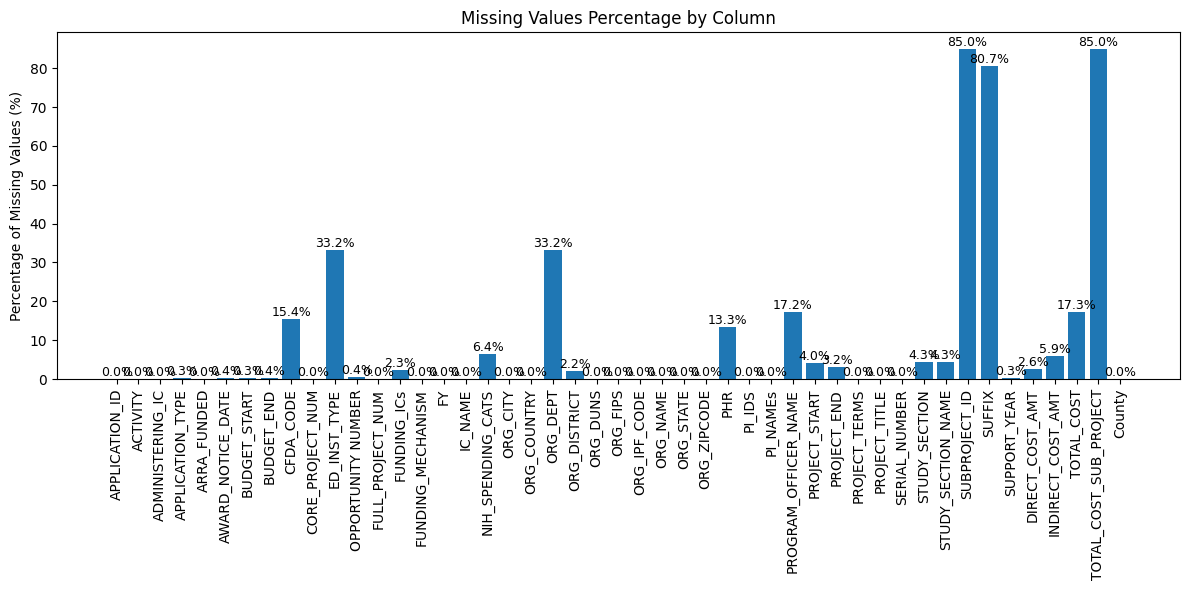

In [ ]:
plot_missing_percentage(final_df_nih)

In [ ]:
final_df_nih[final_df_nih["ORG_STATE"] == "AK"]

,APPLICATION_ID,ACTIVITY,ADMINISTERING_IC,APPLICATION_TYPE,ARRA_FUNDED,AWARD_NOTICE_DATE,BUDGET_START,BUDGET_END,CFDA_CODE,CORE_PROJECT_NUM,ED_INST_TYPE,OPPORTUNITY NUMBER,FULL_PROJECT_NUM,FUNDING_ICs,FUNDING_MECHANISM,FY,IC_NAME,NIH_SPENDING_CATS,ORG_CITY,ORG_COUNTRY,ORG_DEPT,ORG_DISTRICT,ORG_DUNS,ORG_FIPS,ORG_IPF_CODE,ORG_NAME,ORG_STATE,ORG_ZIPCODE,PHR,PI_IDS,PI_NAMEs,PROGRAM_OFFICER_NAME,PROJECT_START,PROJECT_END,PROJECT_TERMS,PROJECT_TITLE,SERIAL_NUMBER,STUDY_SECTION,STUDY_SECTION_NAME,SUBPROJECT_ID,SUFFIX,SUPPORT_YEAR,DIRECT_COST_AMT,INDIRECT_COST_AMT,TOTAL_COST,TOTAL_COST_SUB_PROJECT,County
12825,10360340,R15,AG,1.0,N,2022-01-28,2022-02-01,2025-04-30,866.0,R15AG072369,UNIVERSITY-WIDE,PAR-19-134,1R15AG072369-01A1,NIA:382750\,NON-SBIR/STTR RPGS,2022,NATIONAL INSTITUTE ON AGING,Aging;American Indian or Alaska Native;Arctic;...,ANCHORAGE,UNITED STATES,NONE,0.0,076664986,US,1078604.0,UNIVERSITY OF ALASKA ANCHORAGE,AK,995084614,Project Narrative/Relevance Approximately 43% ...,15713877 (contact),"HOWELL, BRITTENY M (contact)","RICE, ELISE",2022-02-01,2025-04-30,Address;Affect;Aging;aging population;Alaska;A...,A Health Education Program to Increase Hope an...,72369.0,SPIP,"Social Psychology, Personality and Interperson...",NaN,A1,1.0,250000.0,132750.0,382750.0,NaN,Anchorage Municipality
72116,10574028,R21,NS,1.0,N,2022-09-19,2022-09-20,2025-08-31,853.0,R21NS130270,SCHOOLS OF ARTS AND SCIENCES,PA-21-219,1R21NS130270-01,NINDS:414812\,NON-SBIR/STTR RPGS,2022,NATIONAL INSTITUTE OF NEUROLOGICAL DISORDERS A...,Brain Disorders;Digestive Diseases;Genetics;Li...,ANCHORAGE,UNITED STATES,BIOLOGY,0.0,076664986,US,1078604.0,UNIVERSITY OF ALASKA ANCHORAGE,AK,995084614,Wilson Disease is an inherited disorder that r...,7984767 (contact),"BURKHEAD, JASON L (contact)","MORRIS, JILL A",2022-09-20,2025-08-31,Age;Age of Onset;alternative treatment;Alzheim...,The Atp7b-/- mouse model of neurological coppe...,130270.0,CDIN,Chronic Dysfunction and Integrative Neurodegen...,NaN,NaN,1.0,275000.0,139812.0,414812.0,NaN,Anchorage Municipality
63662,10712709,R16,GM,1.0,N,2023-08-01,2023-08-01,2024-07-31,859.0,R16GM150455,SCHOOLS OF ARTS AND SCIENCES,PAR-21-173,1R16GM150455-01,NIGMS:198448\,NON-SBIR/STTR RPGS,2023,NATIONAL INSTITUTE OF GENERAL MEDICAL SCIENCES,Behavioral and Social Science;Building Researc...,FAIRBANKS,UNITED STATES,CHEMISTRY,NaN,615245164,US,1078602.0,UNIVERSITY OF ALASKA FAIRBANKS,AK,997757880,NARRATIVE. Tobacco use is the leading cause of...,15183573 (contact),"WELTZIN, MAEGAN M (contact)","PEI, WUHONG",2023-08-01,2027-07-31,Accounting;Address;Adult;Affect;Agonist;Alaska...,Visinin-like protein-1 modulation of nicotinic...,150455.0,ZGM1,Special Emphasis Panel[ZGM1 RCB-W (SF)],NaN,NaN,1.0,128031.0,70417.0,198448.0,NaN,Fairbanks North Star Borough


In [ ]:
final_df_nih[final_df_nih["ORG_STATE"] == "AL"]['FY'].unique()

array([2019, 2020, 2021, 2022, 2023], dtype=int64)

In [ ]:
final_df_nih.to_csv("nih_funding_by_state_cleaned.csv", index=False)

### Funding Allocation Features

In [ ]:
def create_funding_features(df):
    """
    Category D: Funding Allocation Features

    Primary outcome variables showing how NIH distributes Alzheimer's research
    funding across states. Critical for testing funding-burden alignment.
    """
    print("\n[NIH] Creating Funding Features...")

    # D1. Basic funding metrics
    funding = df.groupby(['ORG_STATE', 'FY']).agg({
        'TOTAL_COST': ['sum', 'mean', 'median', 'std'],
        'DIRECT_COST_AMT': 'sum',
        'INDIRECT_COST_AMT': 'sum',
        'CORE_PROJECT_NUM': 'nunique',
        'APPLICATION_ID': 'count'
    }).reset_index()

    # Flatten column names
    funding.columns = ['State_Code', 'Year',
                      'Total_Funding_Annual', 'Mean_Award_Size',
                      'Median_Award_Size', 'Award_Size_StdDev',
                      'Total_Direct_Cost', 'Total_Indirect_Cost',
                      'Number_Of_Projects', 'Number_Of_Applications']

    # Convert to millions
    funding['Total_Funding_Millions'] = funding['Total_Funding_Annual'] / 1e6
    funding['Mean_Award_Millions'] = funding['Mean_Award_Size'] / 1e6

    # Indirect cost ratio
    funding['Indirect_Cost_Ratio'] = (
        funding['Total_Indirect_Cost'] / funding['Total_Direct_Cost']
    )

    print(f"   ✓ Created 11 basic funding metrics")

    # D2. Temporal funding patterns
    funding = funding.sort_values(['State_Code', 'Year'])

    funding['Funding_YoY_Change_Pct'] = funding.groupby('State_Code')[
        'Total_Funding_Annual'].pct_change() * 100

    funding['Projects_YoY_Change'] = funding.groupby('State_Code')[
        'Number_Of_Projects'].diff()

    funding['Funding_3Yr_Rolling_Avg'] = funding.groupby('State_Code')[
        'Total_Funding_Annual'].transform(lambda x: x.rolling(3, min_periods=1).mean())

    # Funding trend slope
    def calc_slope(group):
        if len(group) < 3:
            return np.nan
        x = np.arange(len(group))
        y = group.values
        if np.all(np.isnan(y)):
            return np.nan
        valid = ~np.isnan(y)
        if np.sum(valid) < 2:
            return np.nan
        slope, _ = np.polyfit(x[valid], y[valid], 1)
        return slope

    funding['Funding_Trend_Slope'] = funding.groupby(['State_Code'])[
        'Total_Funding_Annual'].transform(calc_slope)

    # Cumulative funding
    funding['Funding_Cumulative_2018'] = funding.groupby(['State_Code'])[
        'Total_Funding_Annual'].cumsum()

    # Volatility
    funding['Funding_Volatility'] = funding.groupby(['State_Code'])[
        'Total_Funding_Annual'].transform(lambda x: x.rolling(3, min_periods=1).std())

    print(f"   ✓ Created 6 temporal funding features")

    funding_features = funding
    return funding_features

### Research Infrastructure Features

In [ ]:
def create_infrastructure_features(df):
    """
    Category E: Research Infrastructure Features

    Control variables capturing research capacity that may explain funding
    independent of disease burden (e.g., presence of major universities).
    """
    print("\n[NIH] Creating Research Infrastructure Features...")

    infra = df.groupby(['ORG_STATE', 'FY']).agg({
        'ORG_NAME': 'nunique',
        'PI_IDS': 'nunique',
        'CORE_PROJECT_NUM': 'nunique'
    }).reset_index()

    infra.columns = ['State_Code', 'Year', 'Number_Of_Institutions',
                    'Number_Of_PIs', 'Number_Of_Unique_Projects']

    # Count institution types if available
    if 'ED_INST_TYPE' in df.columns:
        # Universities
        uni_count = df[
            df['ED_INST_TYPE'].str.contains('UNIVERSITY|COLLEGE', na=False, case=False)
        ].groupby(['ORG_STATE', 'FY'])['ORG_NAME'].nunique().reset_index()
        uni_count.columns = ['State_Code', 'Year', 'Number_Of_Universities']

        infra = infra.merge(uni_count, on=['State_Code', 'Year'], how='left')
        infra['Number_Of_Universities'] = infra['Number_Of_Universities'].fillna(0)

        # SCHOOLS
        uni_count = df[
            df['ED_INST_TYPE'].str.contains('SCHOOLS', na=False, case=False)
        ].groupby(['ORG_STATE', 'FY'])['ORG_NAME'].nunique().reset_index()
        uni_count.columns = ['State_Code', 'Year', 'Number_Of_Schools']

        infra = infra.merge(uni_count, on=['State_Code', 'Year'], how='left')
        infra['Number_Of_Schools'] = infra['Number_Of_Schools'].fillna(0)

        # Medical centers
        med_count = df[
            df['ED_INST_TYPE'].str.contains('HOSPITAL|MEDICAL|CENTERS|UNIT', na=False, case=False)
        ].groupby(['ORG_STATE', 'FY'])['ORG_NAME'].nunique().reset_index()
        med_count.columns = ['State_Code', 'Year', 'Number_Of_Medical_Centers']

        infra = infra.merge(med_count, on=['State_Code', 'Year'], how='left')
        infra['Number_Of_Medical_Centers'] = infra['Number_Of_Medical_Centers'].fillna(0)

    # Calculate concentration (Herfindahl index approximation)
    # Top institution's share of funding
    top_share = df.groupby(['ORG_STATE', 'FY', 'ORG_NAME'])['TOTAL_COST'].sum().reset_index()
    top_share = top_share.sort_values('TOTAL_COST', ascending=False)

    def calc_top_share(group):
        total = group['TOTAL_COST'].sum()
        if total == 0:
            return np.nan
        return group.iloc[0]['TOTAL_COST'] / total * 100

    top_inst = top_share.groupby(['ORG_STATE', 'FY']).apply(calc_top_share).reset_index()
    top_inst.columns = ['State_Code', 'Year', 'Top_Institution_Funding_Share']

    infra = infra.merge(top_inst, on=['State_Code', 'Year'], how='left')

    # PIs per institution
    infra['PIs_Per_Institution'] = (
        infra['Number_Of_PIs'] / infra['Number_Of_Institutions']
    )

    print(f"   ✓ Created infrastructure features")

    infrastructure_features = infra
    return infrastructure_features

### Extract NIH Features

In [ ]:
def get_all_nih_features(final_df_nih):

    funding_features = create_funding_features(final_df_nih)
    infrastructure_features = create_infrastructure_features(final_df_nih)

    """Merge all NIH features into one dataset"""
    print("\n[NIH] Merging all features...")

    # Start with funding features
    final = funding_features.copy()

    # Merge infrastructure
    final = final.merge(infrastructure_features,
                       on=['State_Code', 'Year'], how='left')

    print(f"   ✓ Final NIH dataset: {final.shape}")
    print(f"   ✓ Features: {len(final.columns)}")
    print(f"   ✓ States: {final['State_Code'].nunique()}")
    print(f"   ✓ Years: {final['Year'].nunique()}")

    return final

In [ ]:
final_df_nih = get_all_nih_features(final_df_nih)


[NIH] Creating Funding Features...
   ✓ Created 11 basic funding metrics
   ✓ Created 6 temporal funding features

[NIH] Creating Research Infrastructure Features...
   ✓ Created infrastructure features

[NIH] Merging all features...
   ✓ Final NIH dataset: (257, 27)
   ✓ Features: 27
   ✓ States: 53
   ✓ Years: 5


### Merge NIH and CDC datasets

In [ ]:
def merge_datasets(cdc, nih):
    """
    Merge CDC and NIH data on State_Code and Year

    This creates the complete state-year panel dataset for analysis.
    """
    print("\n" + "="*80)
    print("MERGING CDC AND NIH DATASETS")
    print("="*80)

    print("\n[1/5] Merging datasets...")

    # Merge on State_Code and Year
    merged = cdc.merge(
        nih,
        on=['State_Code', 'Year'],
        how='inner',
        indicator=True
    )

    print(f"   ✓ Merged dataset shape: {merged.shape}")
    print(f"\nMerge Statistics:")
    print(merged['_merge'].value_counts())

    # Keep only records with both CDC and NIH data for main analysis
    complete_data = merged[merged['_merge'] == 'both'].copy()
    complete_data = complete_data.drop('_merge', axis=1)

    print(f"\n   ✓ Complete cases (both CDC & NIH): {len(complete_data)}")
    print(f"   ✓ States with complete data: {complete_data['State_Code'].nunique()}")

    merged_data = complete_data
    return merged_data

In [ ]:
merged_data = merge_datasets(final_cdc_df, final_df_nih)


MERGING CDC AND NIH DATASETS

[1/5] Merging datasets...
   ✓ Merged dataset shape: (250, 61)

Merge Statistics:
_merge
both          250
left_only       0
right_only      0
Name: count, dtype: int64

   ✓ Complete cases (both CDC & NIH): 250
   ✓ States with complete data: 51


In [ ]:
merged_data.head()

,State,Year,Deaths,Population,Total_Deaths_Annual,Mortality_Rate_Per_100k,Mortality_Rank_National,Mortality_Percentile,Mortality_YoY_Change_Pct,Deaths_YoY_Change_Pct,Mortality_3Yr_Rolling_Avg,Mortality_Trend_Slope,Deaths_Cumulative_2018,Mortality_Volatility,County_Burden_Concentration,High_Burden_County_Count,Total_Population,Population_65plus,Population_85plus,Population_75_84,Pct_Population_65plus,Pct_Population_85plus,Pct_Population_75_84,Working_Age_Population,Elderly_Dependency_Ratio,Very_Old_Ratio,Age_65plus_YoY_Growth,Age_85plus_YoY_Growth,Deaths_Female,Deaths_Male,Mortality_Rate_Female,Mortality_Rate_Male,Female_Male_Death_Ratio,Female_Pct_Of_Deaths,State_Code,Total_Funding_Annual,Mean_Award_Size,Median_Award_Size,Award_Size_StdDev,Total_Direct_Cost,Total_Indirect_Cost,Number_Of_Projects,Number_Of_Applications,Total_Funding_Millions,Mean_Award_Millions,Indirect_Cost_Ratio,Funding_YoY_Change_Pct,Projects_YoY_Change,Funding_3Yr_Rolling_Avg,Funding_Trend_Slope,Funding_Cumulative_2018,Funding_Volatility,Number_Of_Institutions,Number_Of_PIs,Number_Of_Unique_Projects,Number_Of_Universities,Number_Of_Schools,Number_Of_Medical_Centers,Top_Institution_Funding_Share,PIs_Per_Institution
0,Alabama,2019,1011,4876250,1011,20.733145,17.0,68.627451,NaN,NaN,20.733145,-1.767904,1011,NaN,53.214639,3.0,4876250,121044,44938,76106,2.482317,0.921569,1.560749,3023275.00,4.003738,37.125343,<NA>,<NA>,857.0,154.0,17.574981,3.158165,5.564935,84.767557,AL,15325489.0,494370.612903,371250.0,6.170042e+05,11101438.0,4561291.0,33,35,15.325489,0.494371,0.410874,NaN,NaN,1.532549e+07,3651415.6,15325489.0,NaN,6,34,33,0.0,3.0,1.0,83.790083,5.666667
1,Alabama,2020,1464,4893186,1464,29.919157,8.0,86.274510,44.305924,44.807122,25.326151,-1.767904,2475,6.495491,50.273224,4.0,4893186,170981,62292,89672,3.494267,1.273036,1.832589,3033775.32,5.635915,36.432118,41.255246,38.617651,1252.0,212.0,25.586601,4.332556,5.905660,85.519126,AL,19630313.0,478788.121951,371250.0,5.815772e+05,15425902.0,5521003.0,43,47,19.630313,0.478788,0.357905,28.089309,10.0,1.747790e+07,3651415.6,34955802.0,3.043970e+06,7,43,43,0.0,4.0,0.0,91.282477,6.142857
2,Alabama,2021,1234,4997675,1234,24.691482,7.0,88.235294,-17.472670,-15.710383,25.114595,-1.767904,3709,4.607599,59.157212,4.0,4997675,189790,50391,88854,3.797566,1.008289,1.777907,3098558.50,6.125106,26.550925,11.000637,-19.105182,987.0,247.0,19.749183,4.942298,3.995951,79.983793,AL,22465502.0,477989.404255,371250.0,5.392216e+05,17912318.0,6674013.0,46,52,22.465502,0.477989,0.372593,14.442913,3.0,1.914043e+07,3651415.6,57421304.0,3.595126e+06,8,45,46,1.0,4.0,0.0,85.876479,5.625000
3,Alabama,2022,1049,5028092,1049,20.862785,15.0,72.549020,-15.506145,-14.991896,25.157808,-1.767904,4758,4.546159,54.814109,4.0,5028092,154445,41284,95952,3.071642,0.821067,1.908318,3117417.04,4.954262,26.730551,-18.623215,-18.072672,853.0,196.0,16.964686,3.898099,4.352041,81.315539,AL,21919397.0,521890.404762,387763.0,6.221259e+05,18311538.0,6326928.0,42,47,21.919397,0.521890,0.345516,-2.430860,-4.0,2.133840e+07,3651415.6,79340701.0,1.504240e+06,8,43,42,1.0,5.0,0.0,84.357941,5.375000
4,Alabama,2023,830,5054253,830,16.421813,23.0,56.862745,-21.286569,-20.877026,20.658693,-1.767904,5588,4.138610,56.867470,4.0,5054253,114535,33063,81472,2.266111,0.654162,1.611949,3133636.86,3.655018,28.867159,-25.840914,-19.913284,685.0,145.0,13.552942,2.868871,4.724138,82.530120,AL,32438025.0,636039.705882,371250.0,1.204540e+06,27738730.0,7178729.0,53,54,32.438025,0.636040,0.258798,47.987762,11.0,2.560764e+07,3651415.6,111778726.0,5.921585e+06,7,49,53,1.0,5.0,1.0,59.142670,7.000000


### Create lagged features for temporal analysis

In [ ]:
def create_lagged_features(merged_data, lags=[1, 2, 3]):
    """
    Create lagged features for temporal analysis

    Lagged features allow testing whether funding responds to past burden
    (lag burden → predict current funding) or vice versa.
    Essential for answering temporal lag questions in research question.
    """
    print("\n[2/5] Creating lagged features...")

    df = merged_data.copy()
    df = df.sort_values(['State_Code', 'Year'])

    lag_features = [
        'Mortality_Rate_Per_100k',
        'Total_Deaths_Annual',
        'Population_65plus',
        'Population_85plus',
        'Total_Funding_Annual',
        'Number_Of_Projects'
    ]

    for feature in lag_features:
        if feature in df.columns:
            for lag in lags:
                df[f'{feature}_Lag{lag}'] = df.groupby('State_Code')[feature].shift(lag)

    created_lags = [c for c in df.columns if '_Lag' in c]
    print(f"   ✓ Created {len(created_lags)} lagged features")

    merged_data = df
    return merged_data

In [ ]:
merged_data = create_lagged_features(merged_data)


[2/5] Creating lagged features...
   ✓ Created 18 lagged features


In [ ]:
merged_data.head()

,State,Year,Deaths,Population,Total_Deaths_Annual,Mortality_Rate_Per_100k,Mortality_Rank_National,Mortality_Percentile,Mortality_YoY_Change_Pct,Deaths_YoY_Change_Pct,Mortality_3Yr_Rolling_Avg,Mortality_Trend_Slope,Deaths_Cumulative_2018,Mortality_Volatility,County_Burden_Concentration,High_Burden_County_Count,Total_Population,Population_65plus,Population_85plus,Population_75_84,Pct_Population_65plus,Pct_Population_85plus,Pct_Population_75_84,Working_Age_Population,Elderly_Dependency_Ratio,Very_Old_Ratio,Age_65plus_YoY_Growth,Age_85plus_YoY_Growth,Deaths_Female,Deaths_Male,Mortality_Rate_Female,Mortality_Rate_Male,Female_Male_Death_Ratio,Female_Pct_Of_Deaths,State_Code,Total_Funding_Annual,Mean_Award_Size,Median_Award_Size,Award_Size_StdDev,Total_Direct_Cost,Total_Indirect_Cost,Number_Of_Projects,Number_Of_Applications,Total_Funding_Millions,Mean_Award_Millions,Indirect_Cost_Ratio,Funding_YoY_Change_Pct,Projects_YoY_Change,Funding_3Yr_Rolling_Avg,Funding_Trend_Slope,Funding_Cumulative_2018,Funding_Volatility,Number_Of_Institutions,Number_Of_PIs,Number_Of_Unique_Projects,Number_Of_Universities,Number_Of_Schools,Number_Of_Medical_Centers,Top_Institution_Funding_Share,PIs_Per_Institution,Mortality_Rate_Per_100k_Lag1,Mortality_Rate_Per_100k_Lag2,Mortality_Rate_Per_100k_Lag3,Total_Deaths_Annual_Lag1,Total_Deaths_Annual_Lag2,Total_Deaths_Annual_Lag3,Population_65plus_Lag1,Population_65plus_Lag2,Population_65plus_Lag3,Population_85plus_Lag1,Population_85plus_Lag2,Population_85plus_Lag3,Total_Funding_Annual_Lag1,Total_Funding_Annual_Lag2,Total_Funding_Annual_Lag3,Number_Of_Projects_Lag1,Number_Of_Projects_Lag2,Number_Of_Projects_Lag3
5,Alaska,2022,38,734821,38,5.171327,47.0,9.803922,153.722907,153.333333,3.850497,-0.186923,108,1.623368,100.000000,0.0,734821,4439,2436,2003,0.604093,0.331509,0.272583,455589.02,0.974343,54.877225,284.662045,111.091854,38.0,NaN,5.171327,NaN,NaN,NaN,AK,797562.0,398781.000000,398781.0,22671.257618,525000.0,272562.0,2,2,0.797562,0.398781,0.519166,NaN,NaN,7.975620e+05,NaN,797562.0,NaN,1,2,2,1.0,1.0,0.0,100.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
6,Alaska,2023,13,733971,13,1.771187,49.0,5.882353,-65.749855,-65.789474,2.993565,-0.186923,121,1.890717,100.000000,0.0,733971,2041,<NA>,2041,0.278076,<NA>,0.278076,455062.02,0.44851,<NA>,-54.021176,0.0,13.0,NaN,1.771187,NaN,NaN,NaN,AK,198448.0,198448.000000,198448.0,NaN,128031.0,70417.0,1,1,0.198448,0.198448,0.550000,-75.118173,-1.0,4.980050e+05,NaN,996010.0,4.236376e+05,1,1,1,0.0,1.0,0.0,100.000000,1.000000,5.171327,NaN,NaN,38.0,NaN,NaN,4439,<NA>,<NA>,2436,<NA>,<NA>,797562.0,NaN,NaN,2.0,NaN,NaN
0,Alabama,2019,1011,4876250,1011,20.733145,17.0,68.627451,NaN,NaN,20.733145,-1.767904,1011,NaN,53.214639,3.0,4876250,121044,44938,76106,2.482317,0.921569,1.560749,3023275.00,4.003738,37.125343,<NA>,<NA>,857.0,154.0,17.574981,3.158165,5.564935,84.767557,AL,15325489.0,494370.612903,371250.0,617004.235038,11101438.0,4561291.0,33,35,15.325489,0.494371,0.410874,NaN,NaN,1.532549e+07,3651415.6,15325489.0,NaN,6,34,33,0.0,3.0,1.0,83.790083,5.666667,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
1,Alabama,2020,1464,4893186,1464,29.919157,8.0,86.274510,44.305924,44.807122,25.326151,-1.767904,2475,6.495491,50.273224,4.0,4893186,170981,62292,89672,3.494267,1.273036,1.832589,3033775.32,5.635915,36.432118,41.255246,38.617651,1252.0,212.0,25.586601,4.332556,5.905660,85.519126,AL,19630313.0,478788.121951,371250.0,581577.231844,15425902.0,5521003.0,43,47,19.630313,0.478788,0.357905,28.089309,10.0,1.747790e+07,3651415.6,34955802.0,3.043970e+06,7,43,43,0.0,4.0,0.0,91.282477,6.142857,20.733145,NaN,NaN,1011.0,NaN,NaN,121044,<NA>,<NA>,44938,<NA>,<NA>,15325489.0,NaN,NaN,33.0,NaN,NaN
2,Alabama,2021,1234,4997675,1234,24.691482,7.0,88.235294,-17.472670,-15.710383,25.114595,-1.767904,3709,4.607599,59.157212,4.0,4997675,189790,50391,88854,3.797566,1.008289,1.777907,3098558.50,6.125106,26.550925,11.000637,-19.105182,987.0,2

In [ ]:
merged_data = merged_data.drop(columns = ['Population']).merge(pop, on = ['State', 'Year'], how = 'left')

### Create funding-to-burden ratio features

In [ ]:
def create_equity_features(merged_data):
    """
    Create funding-to-burden ratio features

    These ratios measure equity: how funding aligns with need.
    Critical for identifying underserved states in research question.
    """
    print("\n[3/5] Creating equity/ratio features...")

    df = merged_data.copy()

    # Funding per death
    df['Funding_Per_Death'] = df['Total_Funding_Annual'] / df['Total_Deaths_Annual']

    # Funding per 65+ person
    df['Funding_Per_65plus'] = df['Total_Funding_Annual'] / df['Population_65plus']

    # Funding per capita (total population)
    df['Funding_Per_Capita'] = df['Total_Funding_Annual'] / df['Total_Population']

    # Projects per million population
    df['Projects_Per_Million_Pop'] = (
        df['Number_Of_Projects'] / df['Total_Population'] * 1e6
    )

    # Funding per mortality unit (per 100k rate)
    df['Funding_Per_Mortality_Unit'] = (
        df['Total_Funding_Annual'] / df['Mortality_Rate_Per_100k']
    )

    # Deaths per elderly (disease prevalence in at-risk group)
    df['Deaths_Per_100k_Elderly'] = (
        df['Total_Deaths_Annual'] / df['Population_65plus'] * 100000
    )

    equity_features = [c for c in df.columns if 'Per_' in c or 'Ratio' in c]
    print(f"   ✓ Created {len([c for c in equity_features if c not in merged_data.columns])} equity features")

    merged_data = df
    return merged_data

In [ ]:
merged_data = create_equity_features(merged_data)


[3/5] Creating equity/ratio features...
   ✓ Created 6 equity features


### Create composite scores combining multiple indicators

In [ ]:
def create_composite_indices(merged_data):
    """
    Create composite scores combining multiple indicators

    Composite indices summarize complex constructs (burden, capacity, equity)
    into single interpretable scores for analysis.
    """
    print("\n[4/5] Creating composite indices...")

    df = merged_data.copy()

    # Standardize for composites
    scaler = StandardScaler()

    # Overall Burden Index (higher = worse burden)
    burden_vars = ['Mortality_Rate_Per_100k', 'Total_Deaths_Annual', 'Pct_Population_65plus']
    available_burden = [v for v in burden_vars if v in df.columns]

    if len(available_burden) >= 2:
        burden_scaled = scaler.fit_transform(df[available_burden].fillna(0))
        df['Overall_Burden_Index'] = burden_scaled.mean(axis=1)

    # Research Capacity Index
    capacity_vars = ['Number_Of_Institutions', 'Number_Of_PIs', 'Number_Of_Projects']
    available_capacity = [v for v in capacity_vars if v in df.columns]

    if len(available_capacity) >= 2:
        capacity_scaled = scaler.fit_transform(df[available_capacity].fillna(0))
        df['Research_Capacity_Index'] = capacity_scaled.mean(axis=1)

    # Funding-Burden Alignment Score (how well funding matches burden)
    if 'Overall_Burden_Index' in df.columns:
        # Standardize funding
        if 'Total_Funding_Annual' in df.columns:
            funding_scaled = scaler.fit_transform(df[['Total_Funding_Annual']].fillna(0))
            # Alignment = correlation-like measure (both high or both low = good)
            df['Funding_Burden_Alignment'] = -(
                np.abs(funding_scaled.flatten() - df['Overall_Burden_Index'])
            )

    composite_cols = [c for c in df.columns if 'Index' in c or 'Alignment' in c]
    print(f"   ✓ Created {len([c for c in composite_cols if c not in merged_data.columns])} composite indices")

    merged_data = df
    return merged_data

In [ ]:
merged_data = create_composite_indices(merged_data)


[4/5] Creating composite indices...
   ✓ Created 3 composite indices


### Add external socioeconomic and research capacity controls

In [ ]:
def add_external_control_variables(merged_data):
    """
    Add external socioeconomic and research capacity controls

    These control variables are essential for isolating the burden-funding
    relationship from confounders mentioned in research question.

    NOTE: Using synthetic data for demonstration. Replace with:
    - Census Bureau: income, population
    - BEA: state GDP
    - CMS: healthcare expenditure
    - Carnegie Classification: R1 universities
    """
    print("\n[5/5] Adding external control variables...")
    print("   [INFO] Using synthetic data - replace with real external sources")

    df = merged_data.copy()

    r1 = pd.read_csv("r1_institutes.csv")
    df = df.merge(r1.drop(columns = ['State_Code']), on = ['State', 'Year'], how = 'left')

    # Create time-varying controls

    df = df.merge(per_capita_income, on = ['State', 'Year'], how = 'left')
    df = df.rename(columns = {"Per Capita Income" : "Per_Capita_Income"})

    df = df.merge(median_income, on = ['State', 'Year'], how = 'left')
    df = df.rename(columns = {"Median Income" : "Median_Income"})

    # Prior NIH funding (cumulative or lagged)
    df = df.sort_values(['State', 'Year'])
    df['Prior_NIH_Funding_Total'] = df.groupby('State')[
        'Total_Funding_Annual'].shift(1).fillna(0)

    # Rural/urban indicator (synthetic)
    df['Rural_Population_Pct'] = np.random.uniform(10, 60, len(df))

    control_vars = [
        'Num_R1_Universities', 'Median_Income',
        'Per_Capita_Income', 'Prior_NIH_Funding_Total'
    ]
    print(f"   ✓ Added {len(control_vars)} control variables")
    print(f"   ✓ Controls: {control_vars}")

    merged_data = df
    return merged_data

In [ ]:
merged_data = add_external_control_variables(merged_data)


[5/5] Adding external control variables...
   [INFO] Using synthetic data - replace with real external sources
   ✓ Added 4 control variables
   ✓ Controls: ['Num_R1_Universities', 'Median_Income', 'Per_Capita_Income', 'Prior_NIH_Funding_Total']


### Create regional groupings and features

In [ ]:
def create_regional_features(merged_data):
    """
    Create regional groupings and features

    Regional analysis tests whether geographic disparities exist
    independent of burden (part of research question).
    """
    print("\n[BONUS] Creating regional features...")

    df = merged_data.copy()

    # Define Census regions
    region_map = {
        # Northeast
        'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
        'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast',
        'PA': 'Northeast',
        # Midwest
        'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest',
        'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest',
        'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
        # South
        'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South',
        'NC': 'South', 'SC': 'South', 'VA': 'South', 'WV': 'South',
        'AL': 'South', 'KY': 'South', 'MS': 'South', 'TN': 'South',
        'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South',
        'DC': 'South',
        # West
        'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West',
        'NV': 'West', 'NM': 'West', 'UT': 'West', 'WY': 'West',
        'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West', 'WA': 'West'
    }

    df['Region'] = df['State_Code'].map(region_map)

    # Regional averages for comparison
    regional_stats = df.groupby(['Region', 'Year']).agg({
        'Total_Funding_Annual': 'mean',
        'Mortality_Rate_Per_100k': 'mean',
        'Population_65plus': 'mean'
    }).reset_index()

    regional_stats.columns = ['Region', 'Year', 'Regional_Avg_Funding',
                              'Regional_Avg_Mortality', 'Regional_Avg_65plus_Pop']

    df = df.merge(regional_stats, on=['Region', 'Year'], how='left')

    # State deviation from regional average
    df['Funding_vs_Regional_Avg'] = (
        df['Total_Funding_Annual'] - df['Regional_Avg_Funding']
    )

    df['Mortality_vs_Regional_Avg'] = (
        df['Mortality_Rate_Per_100k'] - df['Regional_Avg_Mortality']
    )

    print(f"   ✓ Created regional features")
    print(f"   ✓ Regions: {df['Region'].unique()}")

    merged_data = df
    return merged_data

In [ ]:
merged_data = create_regional_features(merged_data)


[BONUS] Creating regional features...
   ✓ Created regional features
   ✓ Regions: ['South' 'West' 'Northeast' 'Midwest']


### Final Data for Analysis

In [ ]:
def get_final_dataset(merged_data):
    """
    Return final aggregated dataset ready for analysis
    """
    print("\n" + "="*80)
    print("FINAL AGGREGATED DATASET")
    print("="*80)

    df = merged_data.copy()

    print(f"\n📊 Dataset Summary:")
    print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"   Time period: {df['Year'].min():.0f} - {df['Year'].max():.0f}")
    print(f"   States: {df['State_Code'].nunique()}")
    print(f"   State-year observations: {len(df)}")

    print(f"\n📈 Feature Categories:")
    burden_cols = [c for c in df.columns if any(x in c for x in ['Death', 'Mortality', 'Burden'])]
    demo_cols = [c for c in df.columns if any(x in c for x in ['Population', 'Age_', 'Pct_'])]
    funding_cols = [c for c in df.columns if any(x in c for x in ['Funding', 'Award', 'Cost'])]
    infra_cols = [c for c in df.columns if any(x in c for x in ['Institution', 'PI', 'Project', 'Grant'])]
    lag_cols = [c for c in df.columns if 'Lag' in c]
    equity_cols = [c for c in df.columns if 'Per_' in c or 'Ratio' in c]
    control_cols = [c for c in df.columns if any(x in c for x in ['GDP', 'Income', 'Healthcare', 'R1'])]

    print(f"   • Disease Burden: {len(burden_cols)} features")
    print(f"   • Demographics: {len(demo_cols)} features")
    print(f"   • Funding Outcomes: {len(funding_cols)} features")
    print(f"   • Infrastructure: {len(infra_cols)} features")
    print(f"   • Lagged Variables: {len(lag_cols)} features")
    print(f"   • Equity Ratios: {len(equity_cols)} features")
    print(f"   • Control Variables: {len(control_cols)} features")

    print(f"\n⚠️  Missing Data:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    high_missing = missing_pct[missing_pct > 10].sort_values(ascending=False)

    if len(high_missing) > 0:
        print(f"   Columns with >10% missing:")
        for col, pct in high_missing.head(10).items():
            print(f"      • {col}: {pct}%")
    else:
        print(f"   ✓ No columns with >10% missing data")

    print(f"\n✅ Dataset ready for analysis!")

    return df

In [ ]:
final_dataset = get_final_dataset(merged_data)


FINAL AGGREGATED DATASET

📊 Dataset Summary:
   Shape: 250 rows × 98 columns
   Time period: 2019 - 2023
   States: 51
   State-year observations: 250

📈 Feature Categories:
   • Disease Burden: 32 features
   • Demographics: 19 features
   • Funding Outcomes: 26 features
   • Infrastructure: 11 features
   • Lagged Variables: 18 features
   • Equity Ratios: 16 features
   • Control Variables: 3 features

⚠️  Missing Data:
   Columns with >10% missing:
      • Number_Of_Projects_Lag3: 60.8%
      • Total_Funding_Annual_Lag3: 60.8%
      • Population_85plus_Lag3: 60.8%
      • Population_65plus_Lag3: 60.8%
      • Mortality_Rate_Per_100k_Lag3: 60.8%
      • Total_Deaths_Annual_Lag3: 60.8%
      • Total_Deaths_Annual_Lag2: 40.8%
      • Number_Of_Projects_Lag2: 40.8%
      • Total_Funding_Annual_Lag2: 40.8%
      • Population_85plus_Lag2: 40.8%

✅ Dataset ready for analysis!


In [ ]:
final_dataset.head()

,State,Year,Deaths,Total_Deaths_Annual,Mortality_Rate_Per_100k,Mortality_Rank_National,Mortality_Percentile,Mortality_YoY_Change_Pct,Deaths_YoY_Change_Pct,Mortality_3Yr_Rolling_Avg,Mortality_Trend_Slope,Deaths_Cumulative_2018,Mortality_Volatility,County_Burden_Concentration,High_Burden_County_Count,Total_Population,Population_65plus,Population_85plus,Population_75_84,Pct_Population_65plus,Pct_Population_85plus,Pct_Population_75_84,Working_Age_Population,Elderly_Dependency_Ratio,Very_Old_Ratio,Age_65plus_YoY_Growth,Age_85plus_YoY_Growth,Deaths_Female,Deaths_Male,Mortality_Rate_Female,Mortality_Rate_Male,Female_Male_Death_Ratio,Female_Pct_Of_Deaths,State_Code,Total_Funding_Annual,Mean_Award_Size,Median_Award_Size,Award_Size_StdDev,Total_Direct_Cost,Total_Indirect_Cost,Number_Of_Projects,Number_Of_Applications,Total_Funding_Millions,Mean_Award_Millions,Indirect_Cost_Ratio,Funding_YoY_Change_Pct,Projects_YoY_Change,Funding_3Yr_Rolling_Avg,Funding_Trend_Slope,Funding_Cumulative_2018,Funding_Volatility,Number_Of_Institutions,Number_Of_PIs,Number_Of_Unique_Projects,Number_Of_Universities,Number_Of_Schools,Number_Of_Medical_Centers,Top_Institution_Funding_Share,PIs_Per_Institution,Mortality_Rate_Per_100k_Lag1,Mortality_Rate_Per_100k_Lag2,Mortality_Rate_Per_100k_Lag3,Total_Deaths_Annual_Lag1,Total_Deaths_Annual_Lag2,Total_Deaths_Annual_Lag3,Population_65plus_Lag1,Population_65plus_Lag2,Population_65plus_Lag3,Population_85plus_Lag1,Population_85plus_Lag2,Population_85plus_Lag3,Total_Funding_Annual_Lag1,Total_Funding_Annual_Lag2,Total_Funding_Annual_Lag3,Number_Of_Projects_Lag1,Number_Of_Projects_Lag2,Number_Of_Projects_Lag3,Population,Funding_Per_Death,Funding_Per_65plus,Funding_Per_Capita,Projects_Per_Million_Pop,Funding_Per_Mortality_Unit,Deaths_Per_100k_Elderly,Overall_Burden_Index,Research_Capacity_Index,Funding_Burden_Alignment,Num_R1_Universities,Per_Capita_Income,Median_Income,Prior_NIH_Funding_Total,Rural_Population_Pct,Region,Regional_Avg_Funding,Regional_Avg_Mortality,Regional_Avg_65plus_Pop,Funding_vs_Regional_Avg,Mortality_vs_Regional_Avg
0,Alabama,2019,1011,1011,20.733145,17.0,68.627451,NaN,NaN,20.733145,-1.767904,1011,NaN,53.214639,3.0,4876250,121044,44938,76106,2.482317,0.921569,1.560749,3023275.00,4.003738,37.125343,<NA>,<NA>,857.0,154.0,17.574981,3.158165,5.564935,84.767557,AL,15325489.0,494370.612903,371250.0,6.170042e+05,11101438.0,4561291.0,33,35,15.325489,0.494371,0.410874,NaN,NaN,1.532549e+07,3651415.6,15325489.0,NaN,6,34,33,0.0,3.0,1.0,83.790083,5.666667,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,4876250,15158.742829,126.610894,3.142884,6.767496,7.391782e+05,835.233469,0.012858,-0.354683,-0.460267,2,27928,50536,0.0,40.474485,South,3.166708e+07,15.312540,240384.764706,-1.634159e+07,5.420605
1,Alabama,2020,1464,1464,29.919157,8.0,86.274510,44.305924,44.807122,25.326151,-1.767904,2475,6.495491,50.273224,4.0,4893186,170981,62292,89672,3.494267,1.273036,1.832589,3033775.32,5.635915,36.432118,41.255246,38.617651,1252.0,212.0,25.586601,4.332556,5.905660,85.519126,AL,19630313.0,478788.121951,371250.0,5.815772e+05,15425902.0,5521003.0,43,47,19.630313,0.478788,0.357905,28.089309,10.0,1.747790e+07,3651415.6,34955802.0,3.043970e+06,7,43,43,0.0,4.0,0.0,91.282477,6.142857,20.733145,NaN,NaN,1011.0,NaN,NaN,121044,<NA>,<NA>,44938,<NA>,<NA>,15325489.0,NaN,NaN,33.0,NaN,NaN,4893186,13408.683743,114.809909,4.011765,8.787731,6.561118e+05,856.235488,0.556907,-0.280693,-0.962218,2,28934,52035,15325489.0,17.696297,South,3.782477e+07,19.195833,299064.882353,-1.819445e+07,10.723324
2,Alabama,2021,1234,1234,24.691482,7.0,88.235294,-17.472670,-15.710383,25.114595,-1.767904,3709,4.607599,59.157212,4.0,4997675,189790,50391,88854,3.797566,1.008289,1.777907,3098558.50,6.125106,26.550925,11.000637,-19.105182,987.0,247.0,19.749183,4.942298,3.995951,79.983793,AL,22465502.0,477989.404255,371250.0,5.392216e+05,17912318.0,6674013.0,46,52,22.465502,0.477989,0.372593,14.442913,3.0,1.914043e+07,3651415.6,57421304.0,3.595

In [ ]:
final_dataset[final_dataset['State'] == "Alabama"]

,State,Year,Deaths,Total_Deaths_Annual,Mortality_Rate_Per_100k,Mortality_Rank_National,Mortality_Percentile,Mortality_YoY_Change_Pct,Deaths_YoY_Change_Pct,Mortality_3Yr_Rolling_Avg,Mortality_Trend_Slope,Deaths_Cumulative_2018,Mortality_Volatility,County_Burden_Concentration,High_Burden_County_Count,Total_Population,Population_65plus,Population_85plus,Population_75_84,Pct_Population_65plus,Pct_Population_85plus,Pct_Population_75_84,Working_Age_Population,Elderly_Dependency_Ratio,Very_Old_Ratio,Age_65plus_YoY_Growth,Age_85plus_YoY_Growth,Deaths_Female,Deaths_Male,Mortality_Rate_Female,Mortality_Rate_Male,Female_Male_Death_Ratio,Female_Pct_Of_Deaths,State_Code,Total_Funding_Annual,Mean_Award_Size,Median_Award_Size,Award_Size_StdDev,Total_Direct_Cost,Total_Indirect_Cost,Number_Of_Projects,Number_Of_Applications,Total_Funding_Millions,Mean_Award_Millions,Indirect_Cost_Ratio,Funding_YoY_Change_Pct,Projects_YoY_Change,Funding_3Yr_Rolling_Avg,Funding_Trend_Slope,Funding_Cumulative_2018,Funding_Volatility,Number_Of_Institutions,Number_Of_PIs,Number_Of_Unique_Projects,Number_Of_Universities,Number_Of_Schools,Number_Of_Medical_Centers,Top_Institution_Funding_Share,PIs_Per_Institution,Mortality_Rate_Per_100k_Lag1,Mortality_Rate_Per_100k_Lag2,Mortality_Rate_Per_100k_Lag3,Total_Deaths_Annual_Lag1,Total_Deaths_Annual_Lag2,Total_Deaths_Annual_Lag3,Population_65plus_Lag1,Population_65plus_Lag2,Population_65plus_Lag3,Population_85plus_Lag1,Population_85plus_Lag2,Population_85plus_Lag3,Total_Funding_Annual_Lag1,Total_Funding_Annual_Lag2,Total_Funding_Annual_Lag3,Number_Of_Projects_Lag1,Number_Of_Projects_Lag2,Number_Of_Projects_Lag3,Population,Funding_Per_Death,Funding_Per_65plus,Funding_Per_Capita,Projects_Per_Million_Pop,Funding_Per_Mortality_Unit,Deaths_Per_100k_Elderly,Overall_Burden_Index,Research_Capacity_Index,Funding_Burden_Alignment,Num_R1_Universities,Per_Capita_Income,Median_Income,Prior_NIH_Funding_Total,Rural_Population_Pct,Region,Regional_Avg_Funding,Regional_Avg_Mortality,Regional_Avg_65plus_Pop,Funding_vs_Regional_Avg,Mortality_vs_Regional_Avg
0,Alabama,2019,1011,1011,20.733145,17.0,68.627451,NaN,NaN,20.733145,-1.767904,1011,NaN,53.214639,3.0,4876250,121044,44938,76106,2.482317,0.921569,1.560749,3023275.00,4.003738,37.125343,<NA>,<NA>,857.0,154.0,17.574981,3.158165,5.564935,84.767557,AL,15325489.0,494370.612903,371250.0,6.170042e+05,11101438.0,4561291.0,33,35,15.325489,0.494371,0.410874,NaN,NaN,1.532549e+07,3651415.6,15325489.0,NaN,6,34,33,0.0,3.0,1.0,83.790083,5.666667,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,4876250,15158.742829,126.610894,3.142884,6.767496,7.391782e+05,835.233469,0.012858,-0.354683,-0.460267,2,27928,50536,0.0,40.474485,South,3.166708e+07,15.312540,240384.764706,-1.634159e+07,5.420605
1,Alabama,2020,1464,1464,29.919157,8.0,86.274510,44.305924,44.807122,25.326151,-1.767904,2475,6.495491,50.273224,4.0,4893186,170981,62292,89672,3.494267,1.273036,1.832589,3033775.32,5.635915,36.432118,41.255246,38.617651,1252.0,212.0,25.586601,4.332556,5.905660,85.519126,AL,19630313.0,478788.121951,371250.0,5.815772e+05,15425902.0,5521003.0,43,47,19.630313,0.478788,0.357905,28.089309,10.0,1.747790e+07,3651415.6,34955802.0,3.043970e+06,7,43,43,0.0,4.0,0.0,91.282477,6.142857,20.733145,NaN,NaN,1011.0,NaN,NaN,121044,<NA>,<NA>,44938,<NA>,<NA>,15325489.0,NaN,NaN,33.0,NaN,NaN,4893186,13408.683743,114.809909,4.011765,8.787731,6.561118e+05,856.235488,0.556907,-0.280693,-0.962218,2,28934,52035,15325489.0,17.696297,South,3.782477e+07,19.195833,299064.882353,-1.819445e+07,10.723324
2,Alabama,2021,1234,1234,24.691482,7.0,88.235294,-17.472670,-15.710383,25.114595,-1.767904,3709,4.607599,59.157212,4.0,4997675,189790,50391,88854,3.797566,1.008289,1.777907,3098558.50,6.125106,26.550925,11.000637,-19.105182,987.0,247.0,19.749183,4.942298,3.995951,79.983793,AL,22465502.0,477989.404255,371250.0,5.392216e+05,17912318.0,6674013.0,46,52,22.465502,0.477989,0.372593,14.442913,3.0,1.914043e+07,3651415.6,57421304.0,3.595

In [ ]:
# Define required years
required_years = [2019, 2020, 2021, 2022, 2023]

# Create a MultiIndex of all state-year combinations
states = final_dataset['State'].unique()

full_index = pd.MultiIndex.from_product([states, required_years], names=['State', 'Year'])

# Reindex the DataFrame to include all combinations
final_dataset = final_dataset.set_index(['State', 'Year']).reindex(full_index, fill_value=0).reset_index()

In [ ]:
final_dataset[["State", "Year"]].groupby("State").count()

,Year
State,
Alabama,5
Alaska,5
Arizona,5
Arkansas,5
California,5
Colorado,5
Connecticut,5
Delaware,5
District of Columbia,5


In [ ]:
final_dataset.to_csv("final_dataset_for_analysis.csv", index=False)